# Covariance, correlation and ordinary least sqaures

## Covariance

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

First, we define two random variables with sample size ($n$) 500.

$$
\begin{gathered}
X \sim Exp(\lambda=0.5) \\\\
\epsilon \sim \mathcal{N}(\mu=9, \sigma^2=4) \\\\
Y \sim 3X + \epsilon
\end{gathered}
$$

In [2]:
X = np.random.exponential(scale=2.0, size=500)
Y = 3.0 * X + np.random.normal(loc=9.0, scale=2.0, size=500)

In [3]:
mean_X = np.mean(X)
mean_Y = np.mean(Y)

In [4]:
print(f"E[X] = {mean_X}")
print(f"E[Y] = {mean_Y}")

E[X] = 2.176606250687685
E[Y] = 15.454203979910636


Since we are interested in calculating the covariance, let’s calculate the deviations for both X and Y first.

$$
\begin{gathered}
\text{dev_X} = X_i - \bar{X} \\\\
\text{dev_Y} = Y_i - \bar{Y}
\end{gathered}
$$

In [5]:
dev_X = X - mean_X
dev_X

array([-1.19259067e+00, -6.97703745e-01,  2.47539713e+00, -1.68225515e+00,
       -1.25764411e+00,  1.31762442e+00, -1.52471018e+00,  1.68569523e-02,
       -2.02099428e+00,  5.87421826e-01, -1.29811748e+00,  4.65092567e+00,
       -2.00782332e-01, -3.54259863e-01,  2.01249629e+00, -1.46716096e-01,
        2.57838155e+00, -7.06768587e-01,  2.05334751e+00, -1.15919100e+00,
       -1.68640668e+00,  1.54476108e+01, -2.92592731e-01, -1.67089017e+00,
        1.51283167e+00,  3.89933219e-02, -1.96762162e+00, -1.08684684e+00,
       -1.06707212e+00, -5.22304302e-01, -1.78121511e+00,  7.12468029e+00,
       -2.94119461e-01, -1.25229272e+00, -1.73890522e-01, -1.65658598e-01,
       -1.34752783e+00, -2.00111590e+00, -9.98272088e-01,  1.50744851e+00,
       -2.08186894e+00, -7.98958824e-01, -1.06744477e+00,  1.21773969e+00,
        3.63845308e+00, -1.21648757e+00,  1.89205187e+00, -3.01720554e-01,
       -1.92571834e+00, -1.81947625e+00,  3.50576807e+00,  9.84654080e-01,
       -2.10535266e+00, -

In [6]:
dev_Y = Y - mean_Y
dev_Y

array([-1.39798389e+00, -6.09402904e-01,  7.21480259e+00, -6.98255927e+00,
       -4.46901262e+00,  7.75483439e+00, -4.84178376e+00,  3.58277315e-01,
       -5.74294329e+00,  1.51265026e+00, -4.15280219e+00,  1.55873279e+01,
        1.00550209e+00, -6.23798615e+00,  4.66317257e+00, -1.53417511e+00,
        7.31861366e+00, -1.57962067e+00,  5.36425897e+00, -2.66263254e+00,
       -7.25233975e+00,  4.75644961e+01, -3.68479141e+00, -2.74970782e+00,
        2.50165741e+00, -2.82748191e+00, -8.16764844e+00, -2.25107942e+00,
       -6.82820059e+00, -1.36692710e+00, -5.68779996e+00,  2.28515273e+01,
        1.29566779e+00, -1.24177014e+00, -3.07584573e+00, -2.73318445e+00,
       -3.13859678e-01, -7.03809866e+00, -2.95924596e+00,  6.66290600e+00,
       -4.79387930e+00, -2.84519962e+00, -1.73269056e+00,  7.78879127e+00,
        1.43285899e+01, -4.70525785e+00,  7.48994652e+00, -1.20137504e+00,
       -6.53328968e+00, -5.12499535e+00,  8.72634290e+00,  1.14311749e+00,
       -4.30302897e+00, -

To find the covariance of X and Y, we calculate the mean of the product of the deviations of the two random variables that is the expected value.

$$
Cov(X,Y) = E[\text{dev_X}\cdot\text{dev_Y}]
$$

In [7]:
cov_XY = np.mean(dev_X * dev_Y)
cov_XY

np.float64(14.151274196059228)

In [8]:
cov_matrix = np.cov(X, Y, bias=True)
cov_matrix

array([[ 4.68800542, 14.1512742 ],
       [14.1512742 , 46.32917736]])

As we can see below, NumPy’s built-in method for calculating covariance also yields the same result as the one we derived.

In [9]:
np.isclose(cov_matrix[0][0], np.mean(dev_X * dev_X))

np.True_

## Correlation

The only difference between correlation and covariance is that correlation is normalized.

$$
\begin{gathered}
z_X = \frac{X_i - E[X]}{\sigma_X} \\\\
z_Y = \frac{Y_i - E[Y]}{\sigma_Y}
\end{gathered}
$$

In [10]:
z_X = dev_X / np.std(X, ddof=1)
z_Y = dev_Y / np.std(Y, ddof=1)

While in covariance we directly calculate the mean of the deviations, here we calculate the mean of the Z-scores, which is actually the mean of the standardized deviations.

$$
\rho_{X,Y} = E[z_X z_Y]
$$

In [11]:
corr_XY = np.mean(z_X * z_Y)
corr_XY

np.float64(0.9583071762375327)

As we can see, NumPy’s built-in function also returns very similar values.

In [12]:
print(np.corrcoef(X, Y)[0][1], corr_XY)

0.9602276315005333 0.9583071762375327


## Ordinary Least Squares

When creating an OLS model, we actually build it entirely using covariances and variances. Let's remember the model first:

$$
Y = \beta_0 + \beta_1 X
$$

First, let’s define $\beta_1$:

$$
\beta_1 = \frac{Cov(X,Y)}{Var(X)}
$$

The result of this calculation will tell us how much Y changes for every unit change in X. This makes perfect sense when we consider that covariance measures the “rate of joint change.”

In [13]:
slope = cov_XY / np.var(X)
slope

np.float64(3.0186130200472503)

However, to determine the y-intercept, it is not enough to know the slope; we also need to know the value of Y when X is 0.

To do this, we first swap the variables in our model function: 

$$
\beta_0 = Y - \beta_1 X
$$

Then we substitute $\bar{X}$ and $\bar{Y}$ for X and Y. 

In [14]:
intercept = mean_Y - (slope * mean_X)
intercept

np.float64(8.883872012068561)

In [15]:
model = linregress(X, Y)
model.__getattribute__("slope")

np.float64(3.018613020047249)

We can also see that the values we actually found are correct when we check them using the `linregress` function from `scipy.stats`.

In [16]:
print(
    "Is manuall found intercept and scipy's interecept close?",
    np.isclose(intercept, model.__getattribute__("intercept")),
)
print(
    "Is manuall found slope and scipy's slope close?",
    np.isclose(slope, model.__getattribute__("slope")),
)

Is manuall found intercept and scipy's interecept close? True
Is manuall found slope and scipy's slope close? True


Our goal in linear regression was to minimize the sum of squared errors; below, we can see the sum of squared errors we obtained.

In [17]:
Y_pred = intercept + (slope * X)
residuals = Y - Y_pred
print("Sum of squared errors:", np.sum(residuals**2))

Sum of squared errors: 1805.9784113011574


Here, too, we can see how our data points are distributed in the scatter plot. The line passing through them is the one that minimizes the sum of the squared errors, in other words, our linear regression line.

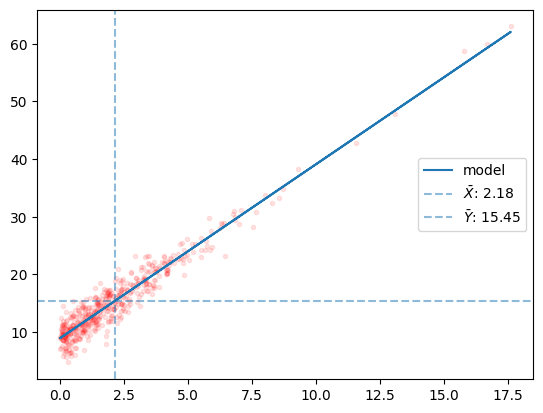

In [18]:
fig, ax = plt.subplots()
ax.scatter(X, Y, alpha=0.1, marker=".", color="red")
ax.plot(X, Y_pred, label="model")
ax.axvline(
    mean_X, ymax=mean_Y, linestyle="--", alpha=0.5, label=f"$\\bar{{X}}$: {mean_X:.2f}"
)
ax.axhline(
    mean_Y, xmax=mean_X, linestyle="--", alpha=0.5, label=f"$\\bar{{Y}}$: {mean_Y:.2f}"
)
ax.legend()
plt.show()

From our graph, we can also see that we have aligned the point where the line intersects the Y-axis ($\beta_0$) with the point where the line passes through the means of both X and Y.

In [19]:
np.isclose((intercept + (slope * mean_X)), mean_Y)

np.True_